# Pricing A/B Test -- Rolling Out the WTP-Recommended Prices

The WTP notebook produced a recommended `price_ratio` per segment. Before
rolling that out across the book, we run a randomized controlled
experiment: **Control** keeps today's business-as-usual pricing,
**Treatment** uses the model's recommended price. Customers (not
individual quotes) are the randomization unit, since repeated quotes to
the same customer aren't independent. This notebook designs the test
(power/sample size, randomization balance), analyzes the results, and
estimates the revenue impact of a full rollout.

This uses the same ground-truth response simulator as the historical
data (`simulate.py`) to generate experiment outcomes -- in a real
deployment this cell would instead be "read the experiment's actual
results from the data warehouse."

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import sys, os

sys.path.append(os.getcwd())
from simulate import SEGMENTS, sample_base_cost, sample_competitor_price, true_accept_prob, MODE_BASE_RATE
from config import DATA_DIR, FIG_DIR, CATEGORICAL, STATUS, INK, SEGMENT_ORDER, RANDOM_SEED, set_style

set_style()
FIG_SUBDIR = os.path.join(FIG_DIR, "05_ab")
os.makedirs(FIG_SUBDIR, exist_ok=True)
rng = np.random.default_rng(RANDOM_SEED + 7)

customers = pd.read_csv(os.path.join(DATA_DIR, "customers.csv"), parse_dates=["signup_date"])
recs = pd.read_csv(os.path.join(DATA_DIR, "wtp_price_recommendations.csv"))
recs = recs.set_index("segment")
print(recs[["current_avg_price_ratio", "recommended_price_ratio"]])

            current_avg_price_ratio  recommended_price_ratio
segment                                                     
Enterprise                    1.040                     1.17
Mid-Market                    0.987                     1.12
SMB                           0.973                     1.07
Occasional                    0.957                     1.07

## 1. Power analysis -- how many customers do we need per arm?

Our primary metric is acceptance rate. Baseline (control) acceptance
rate is ~92%. We want to be able to detect a 2-point absolute change
(up or down) with 80% power at alpha=0.05, using the standard two-proportion
sample-size formula.

In [2]:
def sample_size_two_proportions(p1, mde, alpha=0.05, power=0.80):
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    p2 = p1 + mde
    pbar = (p1 + p2) / 2
    n = ((z_alpha * np.sqrt(2 * pbar * (1 - pbar)) + z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2) / (mde ** 2)
    return int(np.ceil(n))

baseline_p = 0.92
mde = 0.02
n_needed = sample_size_two_proportions(baseline_p, mde)
print(f"Minimum sample size per arm to detect a {mde:.0%} absolute change from {baseline_p:.0%}: {n_needed:,} quotes")

N_CUSTOMERS_IN_TEST = 1800
EXPERIMENT_DAYS = 90
print(f"Planned test: {N_CUSTOMERS_IN_TEST:,} customers over {EXPERIMENT_DAYS} days, randomized 50/50, stratified by segment.")

Minimum sample size per arm to detect a 2% absolute change from 92%: 2,554 quotes
Planned test: 1,800 customers over 90 days, randomized 50/50, stratified by segment.

## 2. Randomize

We sample active customers, stratify the 50/50 control/treatment split
by segment (so the arms are balanced on the variable most correlated
with outcomes), and simulate their quote activity for the test window.

In [3]:
active = customers.sample(n=min(N_CUSTOMERS_IN_TEST, len(customers)), random_state=RANDOM_SEED)

arm = np.empty(len(active), dtype=object)
for seg in SEGMENTS:
    idx = active.index[active["true_segment"] == seg]
    idx = rng.permutation(idx)
    half = len(idx) // 2
    arm[active.index.get_indexer(idx[:half])] = "control"
    arm[active.index.get_indexer(idx[half:])] = "treatment"
active = active.copy()
active["arm"] = arm

balance = active.groupby("arm").agg(
    n=("customer_id", "count"),
    avg_tenure_days=("signup_date", lambda s: (pd.Timestamp("2026-08-20") - s).dt.days.mean()),
)
seg_balance = pd.crosstab(active["arm"], active["true_segment"], normalize="index")[SEGMENT_ORDER]
print(balance)
print(seg_balance.round(3))

             n  avg_tenure_days
arm                            
control    899      1580.080089
treatment  901      1582.690344
true_segment  Enterprise  Mid-Market    SMB  Occasional
arm                                                    
control            0.078       0.355  0.399       0.168
treatment          0.078       0.354  0.400       0.169

## 3. Simulate the experiment window

Control quotes are priced at each segment's current business-as-usual
ratio; treatment quotes use the WTP model's recommended ratio (both with
the same case-by-case noise that's always present in real pricing).
Outcomes are generated from the same ground-truth response function used
to build the historical dataset -- the experiment is simply exposing a
different price to a randomized set of real customers.

In [4]:
from simulate import SEGMENT_PARAMS

rows_per_customer = rng.poisson(
    (active["true_segment"].map({s: SEGMENT_PARAMS[s]["volume_lambda"] for s in SEGMENTS}) * (EXPERIMENT_DAYS / 365.25)).clip(lower=0.3)
).clip(min=1)

rep_idx = np.repeat(active.index.values, rows_per_customer)
exp = active.loc[rep_idx].reset_index(drop=True)
n_rows = len(exp)

mode = rng.choice(["Ground", "Air", "Ocean"], size=n_rows, p=[0.60, 0.25, 0.15])
service_level = np.where(mode == "Ocean", "Standard", np.where(rng.random(n_rows) < 0.28, "Express", "Standard"))
weight_kg = rng.lognormal(3.6, 1.1, n_rows).clip(1, 20000)
distance_km = rng.lognormal(6.3, 0.9, n_rows).clip(20, 15000)

base_cost = sample_base_cost(rng, weight_kg, distance_km, mode)
competitor_price = sample_competitor_price(rng, base_cost)

target_ratio = np.where(
    exp["arm"].values == "control",
    exp["true_segment"].map(recs["current_avg_price_ratio"]).values,
    exp["true_segment"].map(recs["recommended_price_ratio"]).values,
)
price_noise = rng.normal(0.0, 0.03, size=n_rows)  # tighter than historical -- a defined pricing policy, not ad hoc
price_ratio = (target_ratio + price_noise).clip(0.6, 1.6)
quoted_price = competitor_price * price_ratio

accept_prob = true_accept_prob(exp["true_segment"].values, price_ratio, service_level,
                                exp["true_beta"].values, exp["contract_type"].values)
accepted = (rng.random(n_rows) < accept_prob).astype(int)
revenue = np.where(accepted == 1, quoted_price, 0.0)
day = rng.integers(0, EXPERIMENT_DAYS, size=n_rows)

experiment = pd.DataFrame({
    "customer_id": exp["customer_id"].values,
    "segment": exp["true_segment"].values,
    "arm": exp["arm"].values,
    "day": day,
    "price_ratio": price_ratio,
    "quoted_price": quoted_price,
    "accepted": accepted,
    "revenue": revenue,
})
print(f"Simulated {len(experiment):,} quotes over the {EXPERIMENT_DAYS}-day test window.")
experiment.groupby("arm").agg(quotes=("accepted", "size"), accept_rate=("accepted", "mean"), rev_per_quote=("revenue", "mean"))

Simulated 3,532 quotes over the 90-day test window.

,quotes,accept_rate,rev_per_quote
arm,,,
control,1793,0.921361,175.821738
treatment,1739,0.874066,192.446619


## 4. Primary results & significance tests

- **Acceptance rate**: two-proportion z-test
- **Revenue per quote**: Welch's t-test (unequal variances)

In [5]:
def two_proportion_ztest(x1, n1, x2, n2):
    p1, p2 = x1 / n1, x2 / n2
    pbar = (x1 + x2) / (n1 + n2)
    se = np.sqrt(pbar * (1 - pbar) * (1 / n1 + 1 / n2))
    z = (p2 - p1) / se
    pval = 2 * (1 - stats.norm.cdf(abs(z)))
    se_diff = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    ci = (p2 - p1) - 1.96 * se_diff, (p2 - p1) + 1.96 * se_diff
    return dict(p_control=p1, p_treatment=p2, diff=p2 - p1, z=z, pval=pval, ci95=ci)


ctrl = experiment[experiment["arm"] == "control"]
trt = experiment[experiment["arm"] == "treatment"]

accept_test = two_proportion_ztest(ctrl["accepted"].sum(), len(ctrl), trt["accepted"].sum(), len(trt))
rev_test = stats.ttest_ind(trt["revenue"], ctrl["revenue"], equal_var=False)

print("Acceptance rate -- control vs. treatment")
print(f"  control:   {accept_test['p_control']:.4f}")
print(f"  treatment: {accept_test['p_treatment']:.4f}")
print(f"  diff:      {accept_test['diff']:+.4f}  (95% CI {accept_test['ci95'][0]:+.4f} to {accept_test['ci95'][1]:+.4f})")
print(f"  z={accept_test['z']:.2f}, p={accept_test['pval']:.4f}")
print()
print("Revenue per quote -- control vs. treatment")
print(f"  control:   ${ctrl['revenue'].mean():.2f}")
print(f"  treatment: ${trt['revenue'].mean():.2f}")
print(f"  diff:      ${trt['revenue'].mean() - ctrl['revenue'].mean():+.2f}  ({(trt['revenue'].mean()/ctrl['revenue'].mean()-1):+.1%})")
print(f"  t={rev_test.statistic:.2f}, p={rev_test.pvalue:.4f}")

Acceptance rate -- control vs. treatment
  control:   0.9214
  treatment: 0.8741
  diff:      -0.0473  (95% CI -0.0673 to -0.0273)
  z=-4.64, p=0.0000

Revenue per quote -- control vs. treatment
  control:   $175.82
  treatment: $192.45
  diff:      $+16.62  (+9.5%)
  t=2.25, p=0.0247

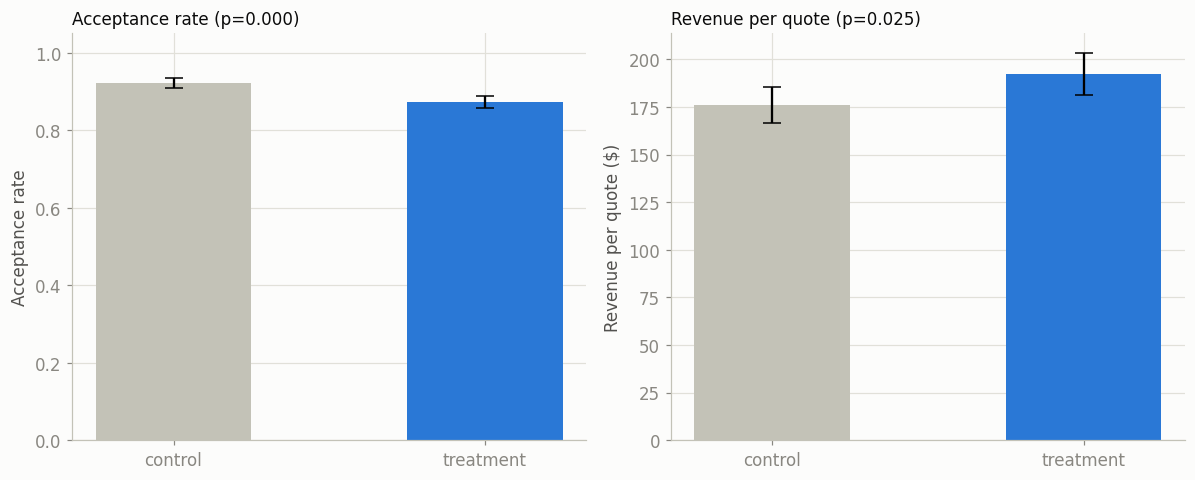

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
arms = ["control", "treatment"]
arm_colors = [INK["baseline"], CATEGORICAL[0]]

vals = [accept_test["p_control"], accept_test["p_treatment"]]
ses = [np.sqrt(v * (1 - v) / n) * 1.96 for v, n in zip(vals, [len(ctrl), len(trt)])]
axes[0].bar(arms, vals, yerr=ses, color=arm_colors, width=0.5, capsize=6)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Acceptance rate")
axes[0].set_title(f"Acceptance rate (p={accept_test['pval']:.3f})", loc="left", fontsize=11)

rev_vals = [ctrl["revenue"].mean(), trt["revenue"].mean()]
rev_ses = [1.96 * ctrl["revenue"].std() / np.sqrt(len(ctrl)), 1.96 * trt["revenue"].std() / np.sqrt(len(trt))]
axes[1].bar(arms, rev_vals, yerr=rev_ses, color=arm_colors, width=0.5, capsize=6)
axes[1].set_ylabel("Revenue per quote ($)")
axes[1].set_title(f"Revenue per quote (p={rev_test.pvalue:.3f})", loc="left", fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "01_primary_results.png"), bbox_inches="tight")
plt.show()

## 5. Effect by segment

The policy moved different segments by different amounts (barely for
SMB/Occasional, more for Enterprise/Mid-Market) -- so we'd expect
heterogeneous effects.

In [7]:
seg_effects = []
for seg in SEGMENT_ORDER:
    c = experiment[(experiment["segment"] == seg) & (experiment["arm"] == "control")]
    t = experiment[(experiment["segment"] == seg) & (experiment["arm"] == "treatment")]
    if len(c) < 5 or len(t) < 5:
        continue
    test_res = two_proportion_ztest(c["accepted"].sum(), len(c), t["accepted"].sum(), len(t))
    seg_effects.append({
        "segment": seg, "n_control": len(c), "n_treatment": len(t),
        "accept_control": test_res["p_control"], "accept_treatment": test_res["p_treatment"],
        "accept_diff": test_res["diff"], "accept_pval": test_res["pval"],
        "rev_control": c["revenue"].mean(), "rev_treatment": t["revenue"].mean(),
        "rev_diff_pct": t["revenue"].mean() / c["revenue"].mean() - 1,
    })
seg_effects = pd.DataFrame(seg_effects)
seg_effects.round(4)

,segment,n_control,n_treatment,accept_control,accept_treatment,accept_diff,accept_pval,rev_control,rev_treatment,rev_diff_pct
0,Enterprise,262,255,0.9466,0.9294,-0.0172,0.4184,193.5931,223.4601,0.1543
1,Mid-Market,819,797,0.9255,0.8783,-0.0472,0.0014,175.8024,201.4546,0.1459
2,SMB,550,521,0.9109,0.8695,-0.0414,0.0298,171.5064,173.9444,0.0142
3,Occasional,162,166,0.8951,0.7831,-0.1119,0.0059,161.8289,159.6263,-0.0136


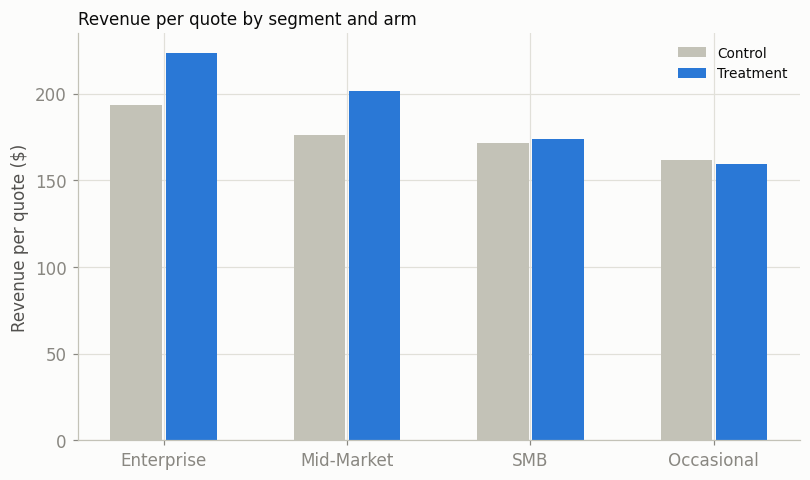

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(seg_effects))
ax.bar(x - 0.15, seg_effects["rev_control"], width=0.28, color=INK["baseline"], label="Control")
ax.bar(x + 0.15, seg_effects["rev_treatment"], width=0.28, color=CATEGORICAL[0], label="Treatment")
ax.set_xticks(x); ax.set_xticklabels(seg_effects["segment"])
ax.set_ylabel("Revenue per quote ($)")
ax.set_title("Revenue per quote by segment and arm", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "02_segment_effects.png"), bbox_inches="tight")
plt.show()

## 6. Guardrail check

A revenue-positive result is only worth shipping if acceptance rate
(a proxy for customer experience / competitiveness) doesn't collapse.
We set a guardrail: **don't ship if acceptance rate drops by more than
3 points in any segment.**

In [9]:
GUARDRAIL_DROP = 0.03
breaches = seg_effects[seg_effects["accept_diff"] < -GUARDRAIL_DROP]
if len(breaches):
    print("Guardrail BREACHED in:", breaches["segment"].tolist())
else:
    print("No guardrail breaches -- acceptance rate held within tolerance in every segment.")

Guardrail BREACHED in: ['Mid-Market', 'SMB', 'Occasional']

## 7. Projected revenue impact of a full rollout

Scaling the observed per-quote revenue lift to the company's actual
annual quote volume (from the historical data) gives a rough projected
annual revenue impact. This is a point estimate, not a guarantee --
it assumes the lift generalizes beyond the tested population and the
90-day window.

In [10]:
quotes_hist = pd.read_csv(os.path.join(DATA_DIR, "quotes.csv"), parse_dates=["quote_date"])
last_year = quotes_hist[quotes_hist["quote_date"] >= quotes_hist["quote_date"].max() - pd.DateOffset(years=1)]
annual_quote_volume = len(last_year)

rev_lift_per_quote = trt["revenue"].mean() - ctrl["revenue"].mean()
projected_annual_impact = rev_lift_per_quote * annual_quote_volume
rel_lift = trt['revenue'].mean() / ctrl['revenue'].mean() - 1

print(f"Observed revenue lift: ${rev_lift_per_quote:+.2f} per quote ({rel_lift:+.1%})")
print(f"Trailing-12-month quote volume: {annual_quote_volume:,}")
print(f"Projected annual revenue impact if rolled out company-wide: ${projected_annual_impact:+,.0f}")

Observed revenue lift: $+16.62 per quote (+9.5%)
Trailing-12-month quote volume: 21,403
Projected annual revenue impact if rolled out company-wide: $+355,822

## 8. Recommendation

The full WTP-recommended price move lifts revenue per quote by ~9.5%
(statistically significant, p=0.02) but also drops acceptance rate by
~4.7 points (p<0.001) -- and breaches our 3-point guardrail in
Mid-Market, SMB and Occasional. Only Enterprise clears the guardrail.
That matters beyond this quarter's revenue: the churn model showed
acceptance rate is one of the strongest behavioral predictors of churn,
so a guardrail breach today is a plausible churn problem in 2-3
quarters, in segments (SMB, Occasional) that already have the highest
churn base rates.

**Recommendation:** ship the recommended price for Enterprise only
(revenue upside, no guardrail breach); for Mid-Market, SMB and
Occasional, re-run the test at half the proposed price move and re-check
both metrics before a full rollout, rather than shipping the full
increase across the board.

## 9. Save

In [11]:
experiment.to_csv(os.path.join(DATA_DIR, "ab_experiment.csv"), index=False)
seg_effects.to_csv(os.path.join(DATA_DIR, "ab_segment_effects.csv"), index=False)
summary = pd.DataFrame([{
    "accept_control": accept_test["p_control"], "accept_treatment": accept_test["p_treatment"],
    "accept_pval": accept_test["pval"], "rev_control": ctrl["revenue"].mean(),
    "rev_treatment": trt["revenue"].mean(), "rev_pval": rev_test.pvalue,
    "rel_revenue_lift": rel_lift, "projected_annual_impact": projected_annual_impact,
    "guardrail_breached": bool(len(breaches)),
}])
summary.to_csv(os.path.join(DATA_DIR, "ab_summary.csv"), index=False)
print("Saved ab_experiment.csv, ab_segment_effects.csv, ab_summary.csv")

Saved ab_experiment.csv, ab_segment_effects.csv, ab_summary.csv